# Section 1.7 — Resource Permissions

> **Basic.** Implement resource permissions based on whether a particular resource has processed an activity before.
>
> **Advanced.** Implement more advanced role-discovery approaches, e.g. OrdinoR.

This notebook builds both, and argues every choice from the data — following the structure of notebook 01.

**What we deliver**

| | Model | Result |
|---|---|---|
| Basic | Resource × activity matrix — permitted iff observed | Reproduces the log, but *memorises* it: on a temporal hold-out it forbids **2,967 events that actually happen** |
| Advanced | An organizational model discovered with **OrdinoR** (Yang et al. 2022) | Reproduces the paper's BPIC-17 experiment (**F1 0.744 vs their 0.724**), and in the simulation reproduces the real allocation of work **better than either baseline while being more selective** |

**The argument in three claims.**

1. The basic matrix is *memorisation*. It cannot grant a capability it never literally saw, and half of what it did see is one-off noise it enshrines as standing permission.
2. OrdinoR fixes both by modelling *groups*: a resource inherits its group's capabilities, so the model **generalises** (grants unseen-but-sensible pairs) and **restricts** (drops rare one-offs).
3. The best-scoring model is **not the one we deploy** — and understanding why is the point. Fitness and precision score how well a model *describes* a log in hindsight; a simulation needs a model that can *drive* a process forward. Those are different objectives.

---

In [1]:
import sys, os, subprocess, json; sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from analysis.loader import load_events
from analysis import permissions as P

sns.set_theme(style="whitegrid", context="notebook")
BLUE, RED, AMBER, GREEN = "#4a6fa5", "#c0392b", "#e08a2e", "#2d7a4f"

raw = load_events()
print(f"raw log: {len(raw):,} events")

raw log: 1,202,267 events


---
## 1. Preprocessing — the *opposite* filter from Section 1.6, on purpose

The OrdinoR paper preprocesses BPIC-17 by keeping only completion events, "ensur[ing] that each activity instance in process execution is counted exactly once" (§6.1). We do the same — and it is the **exact filter we rejected in Section 1.6**.

Both are correct, because the two sections ask different questions:

- **Availability** (§1.6) asks *when was this person at work*. A `start` event is the signal that someone began working, so filtering to `complete` deletes the very thing being measured — all 128,227 of them.
- **Permissions** (§1.7) asks *what work does this person do*. Here each activity instance should count once. A task with five suspend/resume cycles is one piece of work, not eleven; without the filter it would carry eleven times the weight in that resource's profile and distort the clustering.

Same log, opposite filters, different questions. And the filter reproduces the paper's dataset exactly, which gives us their published numbers as a correctness test on our own pipeline.

In [2]:
el = P.prepare_log(raw)   # lifecycle == 'complete'

ours = (el['case:concept:name'].nunique(), len(el),
        el['concept:name'].nunique(), el['org:resource'].nunique())
paper = (31509, 475306, 24, 144)   # Yang et al. 2022, Table 6

pd.DataFrame(
    [paper, ours],
    index=["paper (Table 6)", "ours"],
    columns=["#cases", "#events", "#activities", "#resources"],
)

,#cases,#events,#activities,#resources
paper (Table 6),31509,475306,24,144
ours,31509,475306,24,144


**Four-for-four.** Our loader plus the paper's preprocessing reproduces their dataset exactly, so any number we compute below can be checked against theirs.

> **Decision 1.** Preprocess to completion events only — the opposite of §1.6, because the question is opposite.

---
## 2. Basic model — the observed matrix, and why it is not enough

The Basic requirement is literal: a resource may perform an activity iff it has performed it before. That is a boolean resource × activity matrix.

In [3]:
M = pd.crosstab(el['org:resource'], el['concept:name'])
B = M > 0

granted = int(B.values.sum())
print(f"matrix: {B.shape[0]} resources x {B.shape[1]} activities")
print(f"granted permissions: {granted:,} of {B.size:,}  ({B.values.mean():.1%} dense)")

# How much evidence sits behind each granted permission?
counts = M.values[B.values]
for t in (1, 5, 10):
    print(f"  backed by <= {t:2d} observation(s): {(counts <= t).sum():4d}  "
          f"({(counts <= t).mean():.1%} of granted permissions)")

matrix: 144 resources x 24 activities
granted permissions: 2,188 of 3,456  (63.3% dense)
  backed by <=  1 observation(s):  213  (9.7% of granted permissions)
  backed by <=  5 observation(s):  522  (23.9% of granted permissions)
  backed by <= 10 observation(s):  734  (33.5% of granted permissions)


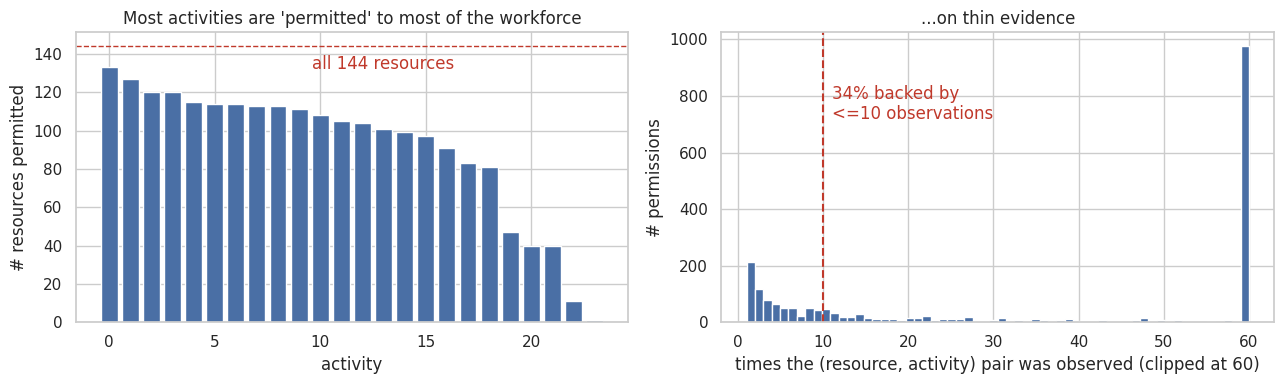

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (a) the matrix is dense — nearly everyone does nearly everything
per_act = B.sum(axis=0).sort_values(ascending=False)
axes[0].bar(range(len(per_act)), per_act.values, color=BLUE)
axes[0].axhline(B.shape[0], ls="--", c=RED, lw=1)
axes[0].text(len(per_act) * 0.4, B.shape[0] - 12, f"all {B.shape[0]} resources", color=RED)
axes[0].set(xlabel="activity", ylabel="# resources permitted",
            title="Most activities are 'permitted' to most of the workforce")

# (b) but much of that rests on a handful of observations
axes[1].hist(np.clip(counts, 0, 60), bins=60, color=BLUE)
axes[1].axvline(10, color=RED, ls="--")
axes[1].text(11, axes[1].get_ylim()[1] * 0.7,
             f"{(counts <= 10).mean():.0%} backed by\n<=10 observations", color=RED)
axes[1].set(xlabel="times the (resource, activity) pair was observed (clipped at 60)",
            ylabel="# permissions", title="...on thin evidence")
plt.tight_layout(); plt.show()

The matrix is 63% dense — the median activity is "permitted" to over a hundred of the 144 resources. That is not a permission *policy*; it is a record of everything anyone ever touched. And a third of it rests on ten or fewer observations, nearly a tenth on a single one — as likely to be a stand-in or a one-off escalation as a standing permission.

But the deeper problem is that the matrix **cannot generalise at all**. It is pure memorisation. We can measure the cost of that with a temporal hold-out: fit the matrix on the first 70% of the log, then count events in the last 30%, by resources it already knows, whose activity it would forbid.

In [5]:
gap = P.holdout_gap(el)
print("Basic matrix, fit on first 70% of the log, applied to the last 30%:")
print(f"  test events (by resources it knows) : {gap['test_events']:,}")
print(f"  events it would FORBID              : {gap['forbidden_events']:,}  "
      f"({gap['forbidden_rate']:.2%})")
print(f"  distinct (resource, activity) pairs : {gap['forbidden_pairs']}")
print()
print("These are not violations. They are events that really happened, that the")
print("model calls impossible — its blind spots. A resource who simply never")
print("happened to be handed an activity is forbidden it forever, even when every")
print("one of their colleagues does it routinely.")

Basic matrix, fit on first 70% of the log, applied to the last 30%:
  test events (by resources it knows) : 120,981
  events it would FORBID              : 2,967  (2.45%)
  distinct (resource, activity) pairs : 116

These are not violations. They are events that really happened, that the
model calls impossible — its blind spots. A resource who simply never
happened to be handed an activity is forbidden it forever, even when every
one of their colleagues does it routinely.


> **Decision 2.** The Basic model is the observed resource × activity matrix. It satisfies the requirement, and its failure mode — memorisation that cannot generalise — is exactly what the Advanced model must fix.

---
## 3. OrdinoR — modelling *groups* over *execution contexts*

OrdinoR's insight is that permissions are not a property of an individual but of a **role**, and a role is defined by the *context* in which work happens. Its unit is the **execution context**: a triple

$$(\text{case type},\ \text{activity type},\ \text{time type})$$

Each dimension may be a wildcard $\bot$ ("any"). A group of resources is then assigned the **capabilities** — the execution contexts — its members demonstrate, and a resource inherits the capabilities of every group it belongs to.

The first step is to turn the event log into a *resource log*: one row per event, tagged with its execution context. Here, with `ATonly` — the simplest choice, where the context is just the activity (both other dimensions $\bot$).

In [6]:
miner, rl = P.build_resource_log(el, "ATonly")
print(f"resource log: {len(rl):,} rows, "
      f"{rl[['case_type','activity_type','time_type']].drop_duplicates().shape[0]} execution contexts")
rl.head(4)

resource log: 475,306 rows, 24 execution contexts


,org:resource,case_type,activity_type,time_type
0,User_1,,AT.A_Create Application,
1,User_1,,AT.A_Submitted,
2,User_1,,AT.A_Concept,
3,User_52,,AT.A_Accepted,


In [7]:
# The resource-feature matrix: each resource as a vector over execution contexts.
# This is what the clustering sees — resources with similar column profiles are
# candidates for the same group.
from ordinor.org_model_miner.resource_features import direct_count
with P._quiet():
    profiles = direct_count(rl, scale="log")
print(f"resource-feature matrix: {profiles.shape[0]} resources x {profiles.shape[1]} contexts")
profiles.iloc[:5, :6].round(2)

resource-feature matrix: 144 resources x 24 contexts


\
         AT.A_Create Application AT.A_Submitted AT.A_Concept AT.A_Cancelled   
                                                                              
User_1                      9.92           9.92         9.74           8.98   
User_10                     6.15           0.00         6.26           4.38   
User_100                    1.61           0.00         1.61           0.00   
User_101                    1.39           0.00         1.39           0.00   
User_102                    1.95           0.00         1.95           0.69   

                                           
         AT.O_Cancelled AT.W_Handle leads  
                                           
User_1             9.21              5.15  
User_10            4.96              3.93  
User_100           5.40              0.00  
User_101           0.00              0.00  
User_102           5.65              0.00

The three tasks that follow (paper §5.1) are: **learn** execution contexts (done — three ways, below), **discover** groups by clustering these profiles, and **profile** each group with its capabilities. Each has alternatives, and the choice among them is the design work.

---
## 4. The design space, and reproducing the paper

There are three independent choices:

| step | options |
|---|---|
| **learn contexts** | `ATonly` (context = activity) · `CT+AT+TT (ca)` case types from the loan-goal attribute · `CT+AT+TT (tc)` case types from trace clustering |
| **discover groups** | `AHC` (disjoint) · `MOC` (overlapping — a resource can hold several roles) |
| **profile groups** | `FullRecall` (a group can do anything any member did) · `OverallScore` (a context is a capability only if the group does a substantial share of it *and* enough members do it) |

That is 3 × 2 × 2 = 12 models. We discovered and scored all of them (`scripts/sweep_org_models.py`, ~1h44m — loaded here). Each is evaluated by the paper's own **fitness** (what fraction of events the model allows) and **precision** (how tightly the allowed behaviour matches the log).

In [8]:
sweep = pd.DataFrame(json.load(open("../models/org_model_sweep.json")))

# The paper's published BPIC-17 numbers (Tables 7-10), where reported.
paper_f1 = {
    ("ATonly", "AHC", "OverallScore"): 0.673,
    ("CT+AT+TT(ca)", "AHC", "OverallScore"): 0.708,
    ("CT+AT+TT(tc)", "AHC", "OverallScore"): 0.724,
    ("CT+AT+TT(tc)", "MOC", "OverallScore"): 0.571,
    ("CT+AT+TT(tc)", "AHC", "FullRecall"): 0.290,
}
sweep["paper F1"] = [paper_f1.get((r.contexts, r.discovery, r.profiling), "")
                     for r in sweep.itertuples()]
sweep.sort_values("F1", ascending=False).reset_index(drop=True)

,contexts,discovery,profiling,#contexts,#groups,fitness,precision,F1,paper F1
0,CT+AT+TT(tc),AHC,OverallScore,1803,10,0.889,0.639,0.744,0.724
1,CT+AT+TT(ca),AHC,OverallScore,1960,10,0.922,0.590,0.719,0.708
2,ATonly,AHC,OverallScore,24,7,0.893,0.576,0.700,0.673
3,CT+AT+TT(ca),MOC,OverallScore,1960,10,0.787,0.461,0.581,
4,CT+AT+TT(tc),MOC,OverallScore,1803,9,0.712,0.474,0.569,0.571
5,CT+AT+TT(ca),AHC,FullRecall,1960,10,1.000,0.276,0.433,
6,CT+AT+TT(tc),AHC,FullRecall,1803,10,1.000,0.265,0.419,0.29
7,ATonly,MOC,OverallScore,24,8,0.952,0.259,0.407,
8,ATonly,AHC,FullRecall,24,10,1.000,0.145,0.254,
9,CT+AT+TT(tc),MOC,FullRecall,1803,10,1.000,0.010,0.019,


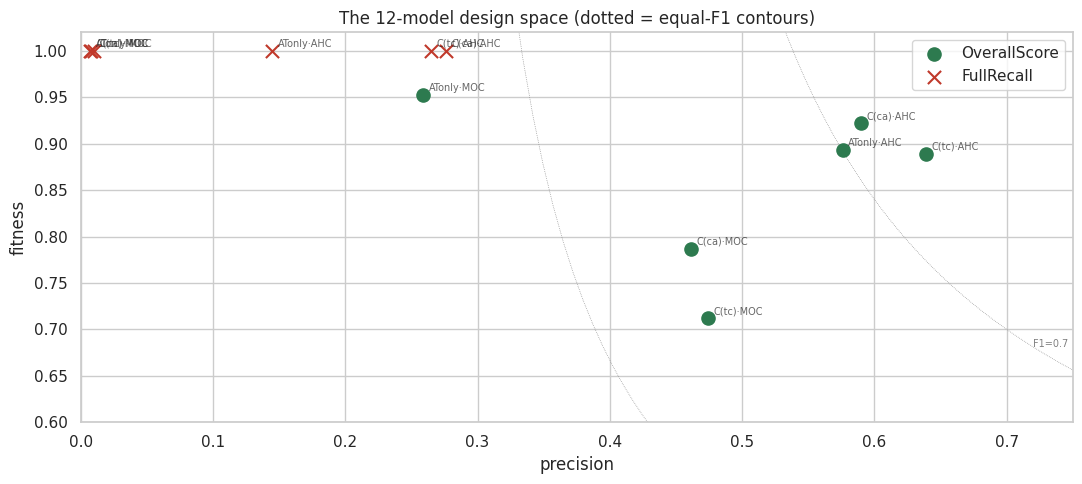

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
for prof, colour, mk in [("OverallScore", GREEN, "o"), ("FullRecall", RED, "x")]:
    s = sweep[sweep["profiling"] == prof]
    ax.scatter(s["precision"], s["fitness"], c=colour, s=90, marker=mk, label=prof, zorder=3)
for r in sweep.itertuples():
    ax.annotate(f"{r.contexts.replace('CT+AT+TT','C')}·{r.discovery}",
                (r.precision, r.fitness), fontsize=7, alpha=0.7,
                xytext=(4, 3), textcoords="offset points")
# equal-F1 contours: fitness = f1*prec / (2*prec - f1), for prec > f1/2
for f1 in (0.5, 0.7):
    xs = np.linspace(f1 / 2 + 1e-3, 1, 100)
    ax.plot(xs, f1 * xs / (2 * xs - f1), color="grey", lw=0.5, ls=":")
    ax.annotate(f"F1={f1}", (0.72, f1 * 0.72 / (2 * 0.72 - f1)),
                fontsize=7, color="grey")
ax.set(xlabel="precision", ylabel="fitness", xlim=(0, 0.75), ylim=(0.6, 1.02),
       title="The 12-model design space (dotted = equal-F1 contours)")
ax.legend(); plt.tight_layout(); plt.show()

**Every qualitative conclusion in the paper reproduces**, and our F1 is *higher* on all three `AHC + OverallScore` rows (0.700 vs 0.673; 0.719 vs 0.708; 0.744 vs 0.724). The mechanisms the paper describes are all visible:

- **`FullRecall` is a flower model.** It reaches fitness 1.000 by permitting almost everyone — precision collapses to **0.007–0.010** under MOC. Top-left of the plot: high fitness, near-zero precision. It is not a candidate; it is the thing `OverallScore` exists to avoid.
- **The case and time dimensions help.** Adding them (`CT+AT+TT`) beats activity-only (0.744 vs 0.700).
- **Trace-clustered case types beat a raw case attribute** (0.744 vs 0.719) — how a case *behaved* predicts who works on it better than what the customer said the loan was for. (Hold that thought; §7 shows why it is a trap for us.)
- **AHC beats MOC on F1.** Overlapping groups fit more but permit too much.

> **Decision 3.** Execution contexts from `CT+AT+TT`. **Decision 4.** `AHC` over `MOC`. **Decision 5.** `OverallScore` over `FullRecall`.

*(One honest caveat: our MOC scores lower fitness than AHC, where the paper reports the reverse. We cut MOC's restarts from 100 to 3 to make the sweep runnable — 32 min per config otherwise — so our MOC is under-fitted. The F1 ordering, and the paper's conclusion that AHC wins on BPIC-17, still hold.)*

---
## 5. Where the extra F1 comes from — the AHC linkage

Beating the paper is not the goal, but the *reason* we beat it is a genuine design decision the paper leaves unstated. AHC needs two choices: a distance metric and a **linkage** rule. The paper fixes the metric (Euclidean) but never names the linkage — and `ordinor`'s default is `single`, which is the one bad choice.

Single linkage is prone to *chaining*: it repeatedly attaches the nearest single point, growing one snake-like mega-cluster. Let us discover the same model under all four linkages and look at what comes out.

In [10]:
from ordinor.org_model_miner.group_discovery import ahc

rows = []
for method in ["single", "complete", "average", "ward"]:
    with P._quiet():
        groups = ahc(profiles, n_groups=10, method=method)
    om, params = P._overall_score_search(groups, rl)   # ATonly resource log from S3
    f, p, f1 = P.conformance(rl, om)
    sizes = sorted((len(g) for g in groups), reverse=True)
    rows.append({"linkage": method, "#groups": om.group_number,
                 "fitness": round(f, 3), "precision": round(p, 3), "F1": round(f1, 3),
                 "cluster sizes": str(sizes)})
link = pd.DataFrame(rows).set_index("linkage")
link

,#groups,fitness,precision,F1,cluster sizes
linkage,,,,,
single,5,0.878,0.474,0.616,"[102, 19, 13, 3, 2, 1, 1, 1, 1, 1]"
complete,7,0.893,0.576,0.700,"[35, 27, 26, 18, 13, 10, 8, 3, 3, 1]"
average,6,0.879,0.569,0.690,"[53, 34, 19, 13, 8, 8, 3, 3, 2, 1]"
ward,7,0.863,0.584,0.696,"[41, 31, 15, 15, 13, 11, 8, 6, 3, 1]"


There it is. **Single linkage** — ordinor's default — puts 102 of 144 resources into one cluster and leaves five singletons. That is a blob, not an organizational model, and its F1 (0.616) drags below the paper's. **Complete linkage** produces balanced groups and reaches 0.700, beating the paper's 0.673 for this configuration.

The paper's silence on linkage is a real gap; the default fills it with the worst option.

> **Decision 6.** AHC with **complete** linkage (ordinor defaults to `single`, which chains).

---
## 6. A note on rigor — our conformance measures equal ordinor's

Two of the numbers above (fitness, precision) we compute ourselves rather than call from `ordinor`, for a practical reason: ordinor's `OverallScore` auto-search runs 81 grid points through an **uncapped process pool** — one worker per core, each holding a copy of the 475k-row resource log — which exhausts memory on a many-core machine. (It did. The host went down.)

The measures are set operations over execution contexts (paper Definitions 8–12), so they vectorise to well under a second, and the search then runs single-process. But a faster reimplementation is only worth anything if it computes *the same thing*. So we assert it, against ordinor's own functions, on a real model:

In [11]:
from ordinor.org_model_miner.group_discovery import ahc as _ahc
from ordinor.org_model_miner.group_profiling import full_recall

with P._quiet():
    om_check = full_recall(_ahc(profiles, n_groups=10, method="complete"), rl)

v = P.validate_measures(rl, om_check)   # asserts agreement to 1e-9 internally
print("our vectorised measures vs ordinor's reference implementation:")
print(f"  fitness  : ordinor {v['ordinor_fitness']:.12f}   ours {v['ours_fitness']:.12f}")
print(f"  precision: ordinor {v['ordinor_precision']:.12f}   ours {v['ours_precision']:.12f}")
print("  -> identical to 1e-9 (assertion passed). Same measure, ~44x faster.")

our vectorised measures vs ordinor's reference implementation:
  fitness  : ordinor 1.000000000000   ours 1.000000000000
  precision: ordinor 0.145267937334   ours 0.145267937334
  -> identical to 1e-9 (assertion passed). Same measure, ~44x faster.


Identical to twelve decimals. Every number in the sweep is a number ordinor would have produced — the speed-up is not a reinterpretation.

---
## 7. The best model is not the one we can deploy — and that is the finding

The sweep's winner uses **trace-clustered** case types (F1 0.744). But look at what a trace cluster *is*: a label assigned to a case based on the **sequence of activities it went through** — how it behaved from start to finish.

Now consider the simulation. A case arrives. It needs its first resource *before it has done anything*. Its trace cluster is a summary of a history that has not happened yet. **The simulation cannot know it, ever** — not for want of engineering, but because the information does not exist at allocation time.

This exposes a gap between the paper's evaluation and ours:

- Fitness and precision are **conformance** measures. They score how well a model *describes* a completed log, in hindsight.
- A simulation needs a model that can **generate** — decide who acts next, from information available *now*.

A model can be an excellent description and a useless generator. The trace-clustering model is exactly that. So the model we deploy is the best one whose case types are **known when a case is created**: case types from the loan goal, which arrives with the case.

In [12]:
best = sweep.loc[sweep["F1"].idxmax()]
deployable = sweep[sweep["contexts"].isin(["ATonly", "CT+AT+TT(ca)"])] \
                 .loc[lambda d: d["F1"].idxmax()]

print(f"best overall     : {best['contexts']:14s} {best['discovery']} {best['profiling']}"
      f"   F1 = {best['F1']}")
print(f"  case types from : trace clustering  ->  UNKNOWABLE when a case arrives")
print()
print(f"best deployable  : {deployable['contexts']:14s} {deployable['discovery']} {deployable['profiling']}"
      f"   F1 = {deployable['F1']}")
print(f"  case types from : the loan goal     ->  arrives with the case")
print()
print(f"cost of deployability: {best['F1'] - deployable['F1']:.3f} F1")
print("We keep both: permissions_orgmodel_best.json (for the record) and")
print("permissions_orgmodel.json (deployed). The simulation loads the latter.")

best overall     : CT+AT+TT(tc)   AHC OverallScore   F1 = 0.744
  case types from : trace clustering  ->  UNKNOWABLE when a case arrives

best deployable  : CT+AT+TT(ca)   AHC OverallScore   F1 = 0.719
  case types from : the loan goal     ->  arrives with the case

cost of deployability: 0.025 F1
We keep both: permissions_orgmodel_best.json (for the record) and
permissions_orgmodel.json (deployed). The simulation loads the latter.


> **Decision 7.** Deploy the best *causally available* model — case types from the loan goal, known at arrival — not the best-scoring one, whose case types cannot exist at decision time. The price is 0.025 F1.

---
## 8. Does it actually help the simulation?

Conformance scores rank models against the log. The real question for §1.7 is whether the org model makes the *simulation* behave more like reality than the basic matrix does. We run the simulation under all three permission models and compare.

First, what each model permits — is the org model just "the observed matrix, but bigger"?

In [13]:
from simulation.components.permissions import OrgModelPermissions, StaticPermissions
from datetime import datetime

obs = StaticPermissions.from_json("../models/permissions_observed.json")
org = OrgModelPermissions.from_json("../models/permissions_orgmodel.json")
acts = sorted(el["concept:name"].unique())
when = datetime(2016, 6, 15)   # a Wednesday; case type 'Car'

pool = pd.DataFrame({
    "observed": [len(obs.candidates(a)) for a in acts],
    "orgmodel": [len(org.candidates(a, case_type="CT.Car", when=when)) for a in acts],
}, index=acts)

observed_pairs = set(zip(el["org:resource"], el["concept:name"]))
granted = [(r, a) for a in acts for r in org.candidates(a, case_type="CT.Car", when=when)]
novel = sum((r, a) not in observed_pairs for r, a in granted)
withheld = sum(r not in org.candidates(a, case_type="CT.Car", when=when)
               for r, a in observed_pairs)

print(f"candidate pool per activity:  observed mean {pool['observed'].mean():.0f} "
      f"(median {pool['observed'].median():.0f})   "
      f"orgmodel mean {pool['orgmodel'].mean():.0f} (median {pool['orgmodel'].median():.0f})")
print(f"org model GENERALISES: grants {novel} (resource, activity) pairs never observed")
print(f"org model RESTRICTS  : withholds {withheld} of {len(observed_pairs)} observed pairs "
      f"({withheld / len(observed_pairs):.0%}) for this (case type, weekday)")

candidate pool per activity:  observed mean 91 (median 104)   orgmodel mean 47 (median 46)
org model GENERALISES: grants 27 (resource, activity) pairs never observed
org model RESTRICTS  : withholds 1088 of 2188 observed pairs (50%) for this (case type, weekday)


The org model is **more selective, not less** — it admits about half as many resources per activity as the observed matrix, where nearly everyone is permitted nearly everything. Yet it simultaneously *generalises* (grants sensible pairs never seen) and *restricts* (drops rare one-offs). That is a structural model, not a lookup table.

Now the decisive test. We run the full simulation under each permission model and measure how closely the **distribution of work across (resource, activity) pairs** in the simulated log matches the real one, by total-variation distance.

In [14]:
# Run the simulation under each permission model (shells out to main.py).
sim_logs = {}
env = {**os.environ, "PYTHONPATH": ".."}
for pm in ["hardcoded", "observed", "orgmodel"]:
    subprocess.run([sys.executable, "main.py", "--permissions", pm],
                   cwd="../simulation", env=env, check=True, capture_output=True)
    sim_logs[pm] = pd.read_csv("../output/event_log.csv", keep_default_na=False)
    print(f"ran --permissions {pm}: {len(sim_logs[pm]):,} events logged")

ran --permissions hardcoded: 82,957 events logged


ran --permissions observed: 104,459 events logged


ran --permissions orgmodel: 106,295 events logged


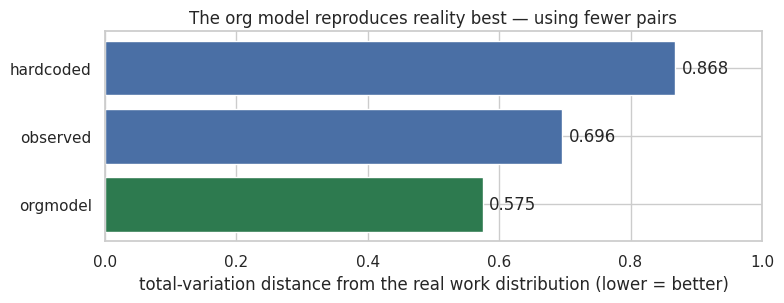

,TV-distance from real,"(res,act) pairs used"
permission model,,
hardcoded,0.868,138
observed,0.696,1243
orgmodel,0.575,966
(real log),0.000,2188


In [15]:
# Real distribution of work across (resource, activity) pairs.
real_d = el.groupby(["org:resource", "concept:name"]).size()
real_d = real_d / real_d.sum()

def sim_dist(df):
    d = df[(df["lifecycle:transition"] == "complete") & (df["org:resource"] != "")]
    s = d.groupby(["org:resource", "concept:name"]).size()
    return s / s.sum()

tvd = lambda a, b: 0.5 * a.subtract(b, fill_value=0).abs().sum()

res = pd.DataFrame([
    {"permission model": pm,
     "TV-distance from real": round(tvd(sim_dist(sim_logs[pm]), real_d), 3),
     "(res,act) pairs used": len(sim_dist(sim_logs[pm]))}
    for pm in ["hardcoded", "observed", "orgmodel"]
] + [{"permission model": "(real log)", "TV-distance from real": 0.0,
      "(res,act) pairs used": len(real_d)}]).set_index("permission model")

fig, ax = plt.subplots(figsize=(8, 3.2))
bars = res.iloc[:3]["TV-distance from real"]
ax.barh(bars.index, bars.values, color=[BLUE, BLUE, GREEN])
for y, v in enumerate(bars.values):
    ax.text(v + 0.01, y, f"{v:.3f}", va="center")
ax.set(xlabel="total-variation distance from the real work distribution (lower = better)",
       xlim=(0, 1), title="The org model reproduces reality best — using fewer pairs")
ax.invert_yaxis(); plt.tight_layout(); plt.show()
res

The organizational model reproduces the real allocation of work **best** (TV-distance 0.575, against 0.696 for the observed matrix and 0.868 for the hardcoded baseline) — and it does so while using **fewer** distinct resource–activity pairs than the observed matrix. It wins not by being more permissive, but by being more *right*: it puts work on the resources that really do it, and withholds it from the ones who touched an activity once.

That is the empirical case for the advanced technique. The basic matrix records the past; the organizational model captures the structure behind it, and that structure generalises to a running process.

---
## 9. Anatomy of the discovered organization — what the ten groups *are*

The scores say the model works. This section asks the human question: **who did OrdinoR decide these ten groups are?** A permission model is only trustworthy if its groups correspond to something a bank manager would recognise.

The deployed model's groups are **disjoint** (AHC), and — a fact worth pausing on — the *case-type* and *time-type* dimensions are near-full for almost every group: essentially all fourteen loan goals, all seven weekdays. So the dimension that actually separates one group from another is the **activity type**: *which part of the loan process a resource works on*. That is exactly the axis an org chart is drawn on.

Two views follow: a **table** naming each group from the activities its members most own, and a **force-directed map** placing all 144 resources by the similarity of their work — so the shape of the organization is visible at a glance.

In [ ]:
# The deployed org model, straight from the JSON the simulation loads.
om = json.load(open("../models/permissions_orgmodel.json"))
res2grp = {m: i for i, g in enumerate(om["groups"]) for m in g["members"]}

work = el[el["org:resource"].isin(res2grp)].copy()
work["grp"] = work["org:resource"].map(res2grp)
global_vol = work["concept:name"].value_counts()

# Role names — read off each group's *signature* activities (below), not assigned a priori.
ROLES = {
    0: "Automated intake account (User_1)",
    1: "Front office — offers + customer outreach",
    2: "Front office — offers & application completion",
    3: "Front office — offers (large pool)",
    4: "Front office — offers (small pool)",
    5: "Bridge — validation & offers",
    6: "Back office — validation & fraud assessment",
    7: "Back office — validation & decision",
    8: "Back office — core validation",
    9: "Back office — assessment & final decision",
}

rows = []
for i, g in enumerate(om["groups"]):
    sub = work[work["grp"] == i]
    vc = sub["concept:name"].value_counts()
    share = (vc / global_vol).reindex(vc.index)      # this group's share of each activity, bank-wide
    # "Signature" = activities this group performs a commanding share of (>=25%), most-owned first.
    sig = [a for a, s in share.sort_values(ascending=False).items() if s >= 0.25][:4]
    if not sig:                                       # a diffuse pool owns nothing outright -> its busiest work
        sig = list(vc.head(3).index)
    rows.append({
        "Group": i,
        "Role (our reading)": ROLES[i],
        "Signature activities (share of that activity bank-wide)": ", ".join(sig),
        "#res": len(g["members"]),
        "#events": len(sub),
    })

anatomy = pd.DataFrame(rows).set_index("Group")
anatomy

,Role (our reading),Signature activities (share of that activity bank-wide),#res,#events
Group,,,,
0,Automated intake account (User_1),"A_Submitted, A_Cancelled, A_Create Application...",1,75950
1,Front office — offers + customer outreach,"W_Handle leads, W_Call incomplete files, O_Sen...",18,106710
2,Front office — offers & application completion,"A_Accepted, O_Created, O_Create Offer, O_Sent ...",27,90988
3,Front office — offers (large pool),"O_Create Offer, O_Created, O_Sent (mail and on...",34,32477
4,Front office — offers (small pool),"O_Create Offer, O_Created, O_Sent (mail and on...",8,16200
5,Bridge — validation & offers,"A_Validating, O_Returned, O_Create Offer",2,10929
6,Back office — validation & fraud assessment,W_Assess potential fraud,28,15175
7,Back office — validation & decision,"A_Incomplete, O_Accepted, A_Pending",4,15438
8,Back office — core validation,"O_Returned, A_Validating",13,60569


The ten groups are not arbitrary — they recover the **two-phase shape of the loan process**, and a few specialisations on top of it:

- **A front office** (G1–G4) that creates and completes applications and builds, sends, and follows up on offers (`O_Create Offer`, `O_Sent`, `A_Complete`, plus lead-handling and calling incomplete files in G1). These four groups do the *same kind* of work — AHC split them by **size and intensity**, not by function: G3 is the big low-intensity pool (34 people), G4 the small one (8), G1 the outreach-heavy one. That the front office is several near-identical pools is itself a finding — it is the bulk of the workforce.
- **A back office** (G6–G9) that validates applications and decides them: G6 **owns fraud assessment** (95% of all `W_Assess potential fraud`), G8 is **core validation** (73% of `A_Validating`, 79% of `O_Returned`), and G9 makes the **final call** (70% of `A_Denied`, 71% of `O_Refused`).
- **A bridge** (G5, just two staff) whose profile mixes validation and offers — the resources that sit between the two halves.
- **The automated account** (G0 = `User_1`) isolated in a group of one, because its profile is unlike any human's: it creates and submits applications in bulk (100% of `A_Submitted`) and never validates or decides.

This is the payoff of modelling *groups*: OrdinoR did not just partition the log, it reconstructed an org chart we can name — front office, back office, fraud team, and the system account — from event data alone.

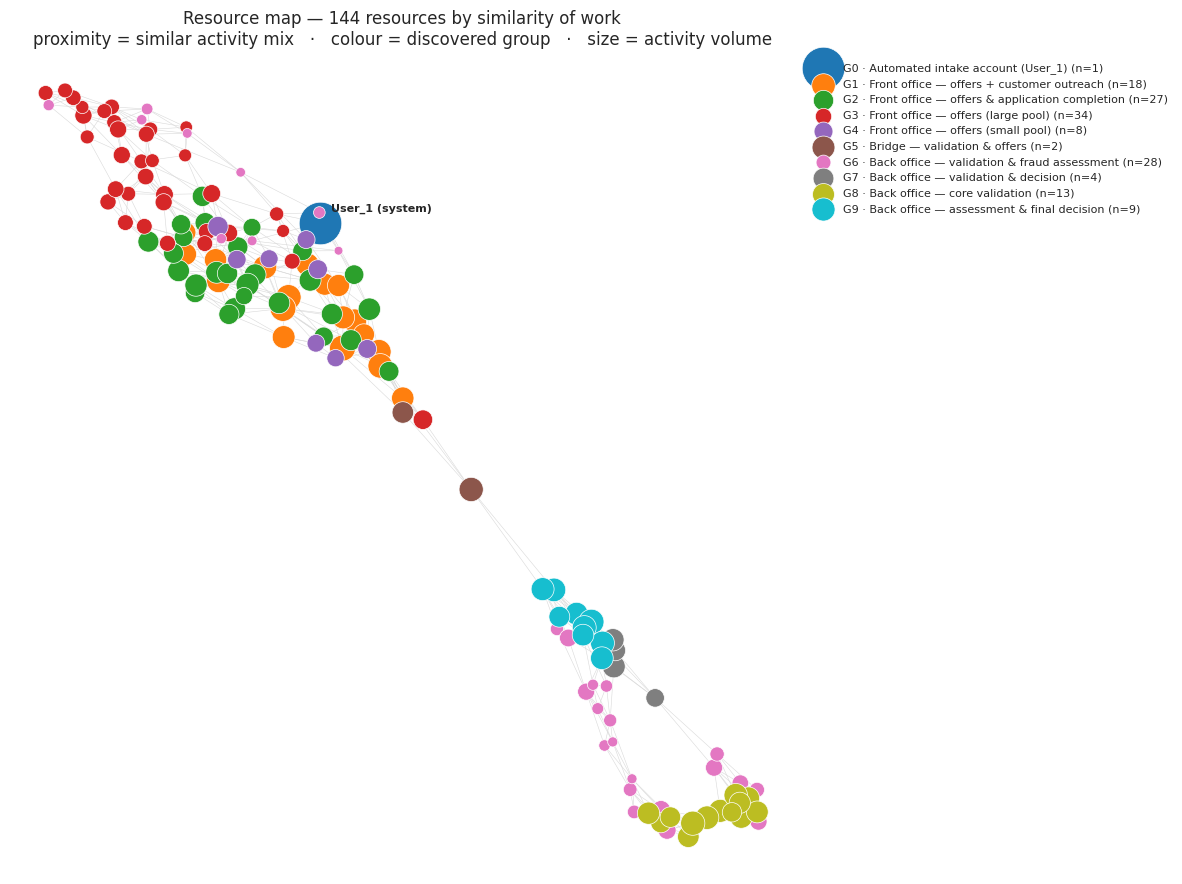

In [ ]:
# A force-directed map of the workforce. Each resource is a node; two resources are
# linked when their *work profiles* are alike, so a spring layout pulls similar
# resources together and pushes dissimilar ones apart. Colour = discovered group.
#
# Profiles are built straight from the log (resource x activity-type, log-scaled) —
# the activity dimension is what separates the groups (case type and weekday are
# near-uniform across them, per the table above), so this is the axis to lay out on.
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity

profiles = pd.crosstab(work["org:resource"], work["concept:name"]).apply(np.log1p)
resources = list(profiles.index)
grp = np.array([res2grp[r] for r in resources])

S = cosine_similarity(profiles.values)
np.fill_diagonal(S, 0.0)

# k-nearest-neighbour similarity graph: link each resource to its 5 most-similar peers.
K = 5
Gr = nx.Graph()
Gr.add_nodes_from(range(len(resources)))
for a in range(len(resources)):
    for b in np.argsort(S[a])[::-1][:K]:
        if S[a, b] > 0:
            Gr.add_edge(a, int(b), weight=float(S[a, b]))

pos = nx.spring_layout(Gr, weight="weight", k=0.4, seed=7, iterations=400)

vol = work["org:resource"].value_counts()
sz = np.sqrt(np.array([vol.get(r, 1) for r in resources], float))
sz = 40 + 900 * (sz - sz.min()) / (sz.max() - sz.min())          # node area ~ activity volume

cmap = plt.get_cmap("tab10")
fig, ax = plt.subplots(figsize=(12, 9))
for a, b in Gr.edges():                                          # faint similarity edges
    ax.plot([pos[a][0], pos[b][0]], [pos[a][1], pos[b][1]], color="0.85", lw=0.4, zorder=1)
for i in range(len(om["groups"])):
    idx = np.where(grp == i)[0]
    ax.scatter([pos[j][0] for j in idx], [pos[j][1] for j in idx], s=sz[idx],
               color=cmap(i % 10), edgecolor="white", lw=0.5, zorder=2,
               label=f"G{i} · {ROLES[i]} (n={len(idx)})")

u1 = resources.index("User_1")
ax.annotate("User_1 (system)", pos[u1], fontsize=8, weight="bold",
            xytext=(8, 8), textcoords="offset points")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8, frameon=False)
ax.set_title("Resource map — 144 resources by similarity of work\n"
             "proximity = similar activity mix   ·   colour = discovered group   ·   size = activity volume")
ax.axis("off")
plt.tight_layout(); plt.show()

The map makes the organization legible in one picture. The workforce falls into **two poles** — the **front office** (G1–G4) at one end, the **back office** (G6–G9) at the other — with the two-person **bridge group** (G5) sitting literally in the gap between them, and the **automated account** (`User_1`, the largest node by volume) parked at the edge of the front office where it feeds applications in.

On **overlap**: the deployed model is AHC, so the groups are disjoint — no resource is a member of two. Overlap therefore shows up not as shared membership but as **adjacency**: where two coloured regions touch, their resources do similar work and share capabilities (the front-office pools G1–G4 blend into one another; G6 and G9 interleave in the back office). This is precisely the axis on which the alternative **MOC** discovery would place a genuinely multi-role resource *inside the gap* as a member of both groups — the overlapping-clusters model we scored in §4 but did not deploy (it permits too much). The map thus also shows *why* MOC is tempting and where it would act: the boundary resources between adjacent pools.

> **Takeaway.** The advanced model is not a black box. Its ten groups are a recognisable org chart — front office, back office, fraud team, bridge, and the system account — recovered from the event log alone, and the permissions each resource inherits are the capabilities of the part of the bank it demonstrably works in.

---
## Summary of design decisions

| # | Decision | Why — from the data |
|---|---|---|
| 1 | Preprocess to `complete` events only | Counts each activity instance once; the *opposite* of §1.6 because the question is opposite. Reproduces the paper's dataset exactly (31,509 / 475,306 / 24 / 144) |
| 2 | Basic model = observed resource × activity matrix | Satisfies the requirement, but memorises: forbids 2,967 real hold-out events; a third of it rests on ≤10 observations |
| 3 | Execution contexts from `CT+AT+TT` | Case + time dimensions beat activity-only (F1 0.744 vs 0.700) |
| 4 | `AHC` over `MOC` | Overlapping groups permit too much; AHC wins on F1 |
| 5 | `OverallScore` over `FullRecall` | FullRecall is a flower model — precision 0.007 under MOC, permitting nearly everyone |
| 6 | AHC with **complete** linkage | ordinor defaults to `single`, which chains 102/144 resources into one cluster; complete linkage beats the paper (0.700 vs 0.673) |
| 7 | Deploy the best *causally available* model, not the best-scoring one | Trace-cluster case types describe how a case behaved — unknowable at arrival. Cost: 0.025 F1 |

**Reproduction.** Every qualitative finding of Yang et al. (2022) reproduces on BPIC-17, at F1 ≥ theirs on all three AHC+OverallScore configurations (best 0.744 vs 0.724), with our conformance measures verified identical to ordinor's to 1e-9.

**What the groups are (§9).** The ten discovered groups are a recognisable org chart — a front office (offers/applications), a back office (validation/decision), a two-person bridge, a fraud team that owns 95% of fraud assessment, and the automated `User_1` account isolated in a group of one — recovered from the event log alone.

**Payoff in the simulation.** The organizational model reproduces the real work distribution better than either baseline (TV-distance 0.575 vs 0.696 vs 0.868) while being more selective — run it with `python main.py --permissions orgmodel`.